## Info 

Here I was playing around with some lambidy stuff, not all that relevant. 

At the bottom is where I have some $p_T$ tests that are useful. 

I will not include this in the git. 

In [12]:
import sympy as sp
from sympy import symbols, cos, sqrt
from IPython.display import display, Math

# Define symbols
s, theta = symbols('s theta', real=True)
m1, m2, m3, m4 = symbols('m1 m2 m3 m4', real=True, nonnegative=True)

# Källén function
def Kallen(s, m1, m2):
    return s**2 + m1**4 + m2**4 - 2*(s*m1**2 + s*m2**2 + m1**2*m2**2)

# General t, u
def t_general(m1, m2, m3, m4, s, theta):
    E1 = (s + m1**2 - m2**2) / (2*sp.sqrt(s))
    E3 = (s + m3**2 - m4**2) / (2*sp.sqrt(s))
    p_i = sp.sqrt(Kallen(s, m1, m2)) / (2*sp.sqrt(s))
    p_f = sp.sqrt(Kallen(s, m3, m4)) / (2*sp.sqrt(s))
    return sp.simplify(m1**2 + m3**2 - 2*(E1*E3 - p_i*p_f*sp.cos(theta)))

def u_general(m1, m2, m3, m4, s, theta):
    E1 = (s + m1**2 - m2**2) / (2*sp.sqrt(s))
    E4 = (s + m4**2 - m3**2) / (2*sp.sqrt(s))
    p_i = sp.sqrt(Kallen(s, m1, m2)) / (2*sp.sqrt(s))
    p_f = sp.sqrt(Kallen(s, m3, m4)) / (2*sp.sqrt(s))
    return sp.simplify(m1**2 + m4**2 - 2*(E1*E4 + p_i*p_f*sp.cos(theta)))

# Define some representative scattering cases
cases = {
    "gg_gg":       (0, 0, 0, 0),
    "gg_qqx":      (0, 0, sp.Symbol('m_q'), sp.Symbol('m_q')),
    "qqx_gg":      (sp.Symbol('m_q'), sp.Symbol('m_q'), 0, 0),
    "gq_gq":       (0, sp.Symbol('m_q'), 0, sp.Symbol('m_q')),
    "gqx_gqx":     (0, sp.Symbol('m_q'), 0, sp.Symbol('m_q')),
    "qqp_qqp":     (sp.Symbol('m_q'), sp.Symbol('m_qp'), sp.Symbol('m_q'), sp.Symbol('m_qp')),
    "qqpx_qqpx":   (sp.Symbol('m_q'), sp.Symbol('m_qp'), sp.Symbol('m_q'), sp.Symbol('m_qp')),
    "qxqpx_qxqpx": (sp.Symbol('m_q'), sp.Symbol('m_qp'), sp.Symbol('m_q'), sp.Symbol('m_qp')),
    "qqx_qpqpx":   (sp.Symbol('m_q'), sp.Symbol('m_q'), sp.Symbol('m_qp'), sp.Symbol('m_qp')),
    "qq_qq":       (sp.Symbol('m_q'), sp.Symbol('m_q'), sp.Symbol('m_q'), sp.Symbol('m_q')),
    "qxqx_qxqx":   (sp.Symbol('m_q'), sp.Symbol('m_q'), sp.Symbol('m_q'), sp.Symbol('m_q')),
    "qqx_qqx":     (sp.Symbol('m_q'), sp.Symbol('m_q'), sp.Symbol('m_q'), sp.Symbol('m_q')),
}


# Print the symbolic formulas cleanly
for name, (m1v, m2v, m3v, m4v) in cases.items():
    display(Math(f"\\textbf{{{name}}}"))
    t_expr = t_general(m1v, m2v, m3v, m4v, s, theta)
    u_expr = u_general(m1v, m2v, m3v, m4v, s, theta)
    display(Math(f"t = {sp.latex(t_expr)}"))
    display(Math(f"u = {sp.latex(u_expr)}"))
    print()  # Just for spacing in console


<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

...

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

In [16]:
import numpy as np
from sympy import symbols, cos, expand, simplify, Rational, lambdify, latex
from IPython.display import display, Math
import matplotlib.pyplot as plt

theta, s = symbols('theta, s')

# This is only true for two outgoing massless particles 
# But because the MEs are for the massless limit then these are what we use 
t = -s/2*(1+cos(theta))
u = -s/2*(1-cos(theta))

A1 = simplify((t**2 + u**2)/s**2)
A2 = simplify((s**2 + t**2)/u**2)
A3 = simplify((s**2 + u**2)/t**2)
A4 = simplify((s**2 + t**2)/(t*s))
A5 = simplify((s**2 + u**2)/(u*s))
A6 = simplify((u**2 + t**2)/(u*t))
A7 = simplify(s**2/(u*t))
A8 = simplify(u**2/(s*t))
A9 = simplify(t**2/(s*u))

gg_gg        = Rational(9,4)*simplify(A2 + A3 + A1 + 3)                     # (1)
gg_qqx       = simplify(Rational(1,6)*A6 - Rational(3,8)*A1)                # (2)
qqx_gg       = simplify(Rational(32,27)*A6 - Rational(8,3)*A1)              # (3)
gq_gq        = simplify(A2 + A3 - Rational(4,9)*(A4 + A5))                  # (4)
gqx_gqx      = simplify(A2 + A3 - Rational(4,9)*(A4 + A5))                  # (5)
qqp_qqp      = Rational(4,9)*simplify(A2+A3)                                # (6)
qqpx_qqpx    = Rational(4,9)*simplify(A2+A3)                                # (7)
qxqpx_qxqpx  = Rational(4,9)*simplify(A2+A3)                                # (8)
qqx_qpqpx    = Rational(4,9)*simplify(A1)                                   # (9)
qq_qq        = simplify(Rational(4,9)*(A2+A3) - Rational(8,27)*A7)          # (10)
qxqx_qxqx    = simplify(Rational(4,9)*(A2+A3) - Rational(8,27)*A7)          # (11)
qqx_qqx      = simplify(Rational(4,9)*(A2+A3+A1) - Rational(8,27)*(A8+A9))  # (12)


pretty_names = {
    "gg_gg":       "gg → gg",
    "gg_qqx":      "gg → qq̄",
    "qqx_gg":      "qq̄ → gg",
    "gq_gq":       "gq → gq",
    "gqx_gqx":     "gq̄ → gq̄",
    "qqp_qqp":     "qq' → qq'",
    "qqpx_qqpx":   "qq̄' → qq̄'",
    "qxqpx_qxqpx": "q̄q̄' → q̄q̄'",
    "qqx_qpqpx":   "qq̄ → q'q̄'",
    "qq_qq":       "qq → qq",
    "qxqx_qxqx":   "q̄q̄ → q̄q̄",
    "qqx_qqx":     "qq̄ → qq̄",
}

processes = {
    "gg_gg":       gg_gg,          # (1)
    "gg_qqx":      gg_qqx,         # (2)
    "qqx_gg":      qqx_gg,         # (3)
    "gq_gq":       gq_gq,          # (4)
    "gqx_gqx":     gqx_gqx,        # (5)
    "qqp_qqp":     qqp_qqp,        # (6)
    "qqpx_qqpx":   qqpx_qqpx,      # (7)
    "qxqpx_qxqpx": qxqpx_qxqpx,    # (8)
    "qqx_qpqpx":   qqx_qpqpx,      # (9)
    "qq_qq":       qq_qq,          # (10)
    "qxqx_qxqx":   qxqx_qxqx,      # (11)
    "qqx_qqx":     qqx_qqx,        # (12)
}

# Ordered keys to preserve (1)-(12) ordering
keys_order = list(processes.keys())

for i, key in enumerate(keys_order, start=1):
    pretty = pretty_names.get(key, key)
    expr = processes[key]
    print(f"({i}) {pretty}")
    display(Math(latex(expr)))
    print()
    
# NOTE: the ME were derived from the high energy limit (i.e. massless quark assumption) so we cannot put mass back into
# u and t all of a sudden here. That is to say we must use the general u and t above 
for i, key in enumerate(keys_order, start=1):
    m1v, m2v, m3v, m4v = cases[key]
    
    t_expr = simplify(t_general(m1v, m2v, m3v, m4v, s, theta))
    u_expr = simplify(u_general(m1v, m2v, m3v, m4v, s, theta))
    
    expr = processes[key]
    
    # substitute t and u into the formula
    expr_sub = simplify(expr.subs({t: t_expr, u: u_expr}))
    
    pretty = pretty_names.get(key, key)
    print(f"({i}) {pretty}")
    display(Math(latex(expr_sub)))
    print()

(1) gg → gg


<IPython.core.display.Math object>


(2) gg → qq̄


<IPython.core.display.Math object>


(3) qq̄ → gg


...

<IPython.core.display.Math object>


(11) q̄q̄ → q̄q̄


<IPython.core.display.Math object>


(12) qq̄ → qq̄


<IPython.core.display.Math object>

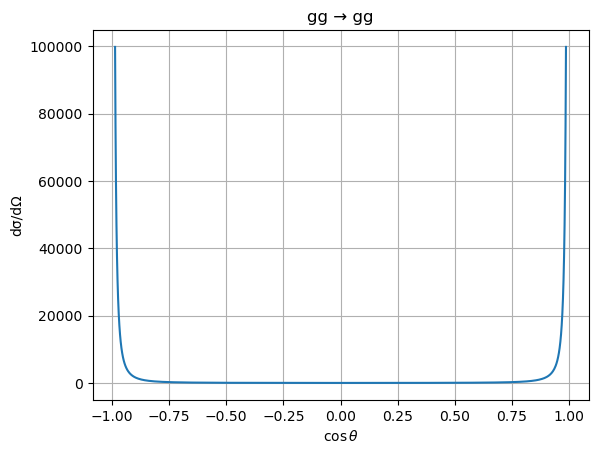

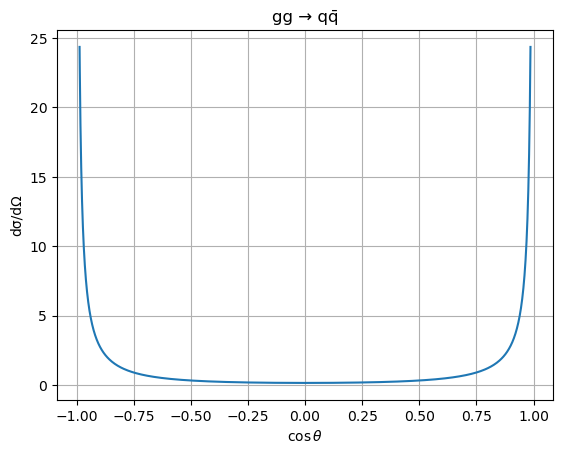

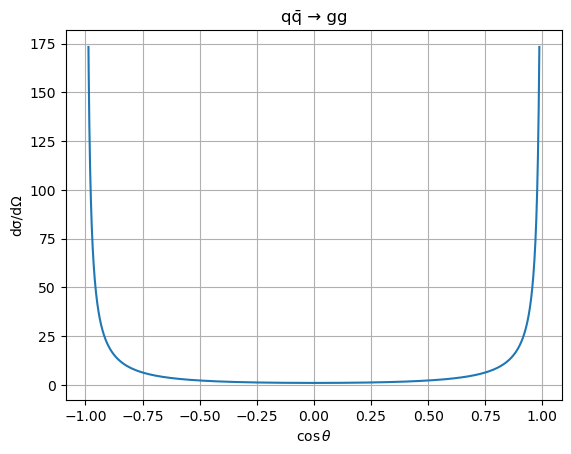

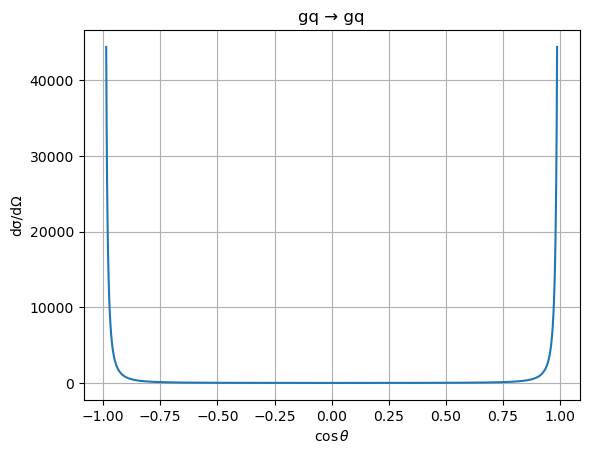

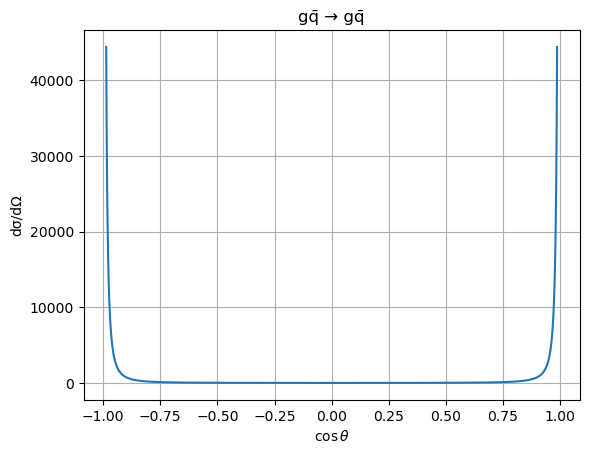

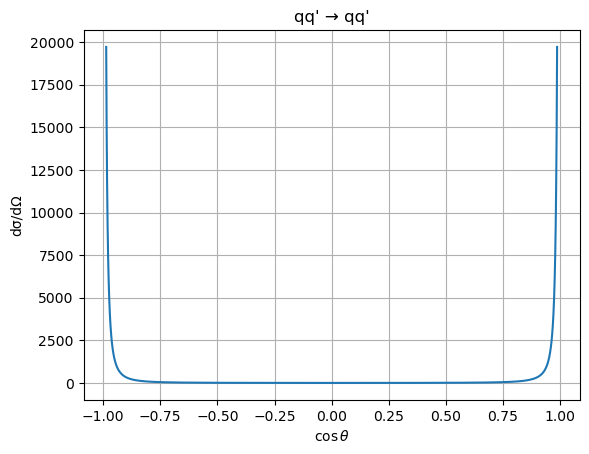

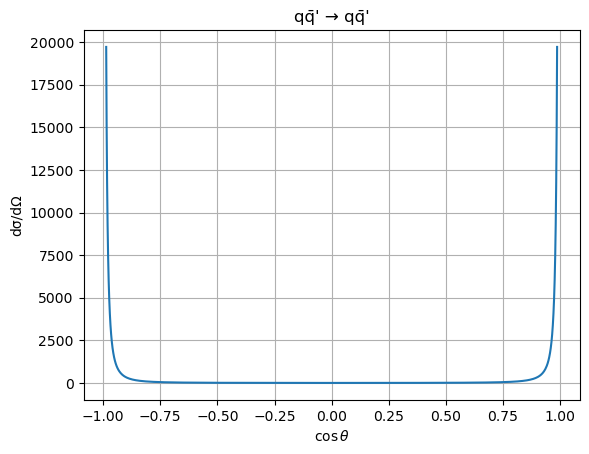

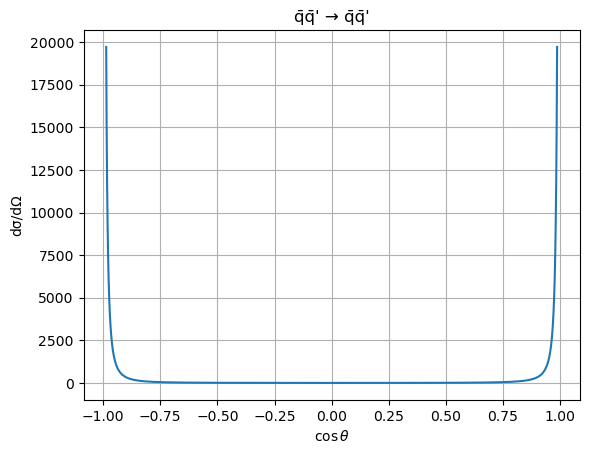

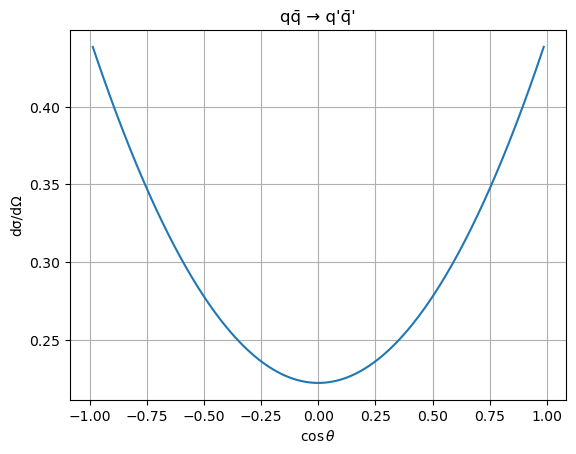

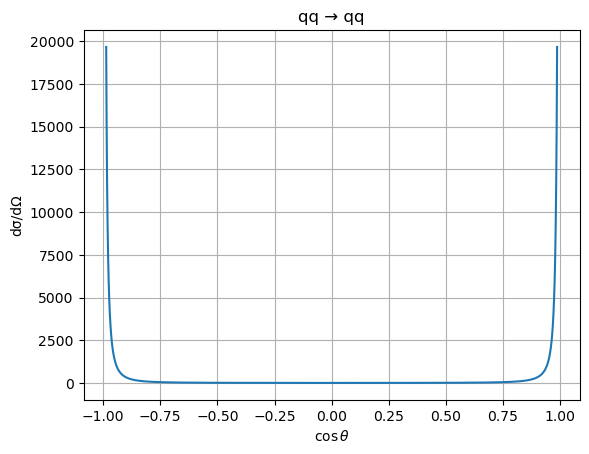

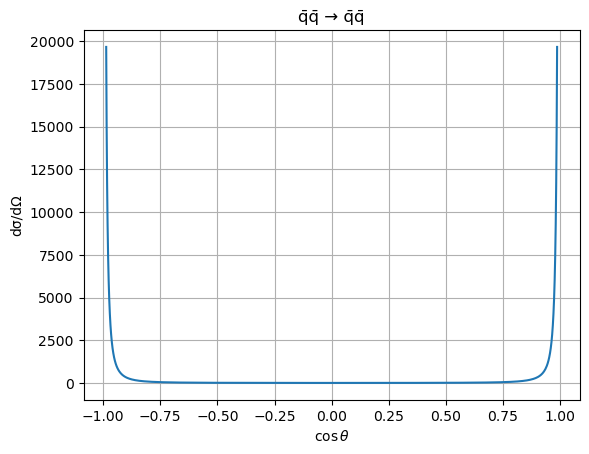

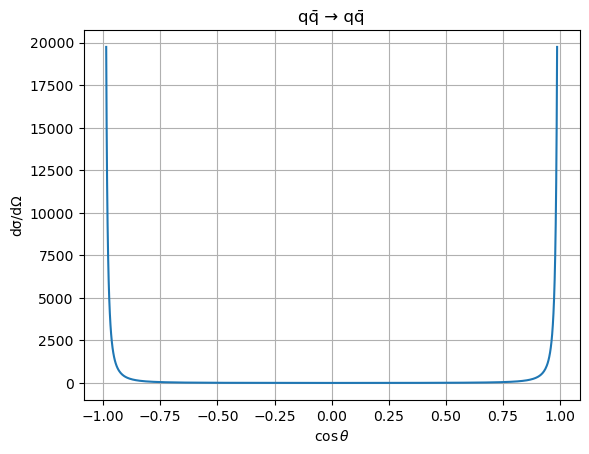

In [18]:
eps = 2 * np.arctan(np.exp(-2.5))  # cut away forward/backward singularities
x = np.linspace(0 + eps, np.pi - eps, 500)  # theta values
cosx = np.cos(x)
sinx = np.sin(x)

for key, expr in processes.items():
    f = lambdify(theta, expr, "numpy")
    y = f(x)

    plt.figure()
    plt.plot(cosx, y)
    # plt.plot(x,y)
    plt.xlabel(r"$\cos\theta$")
    plt.ylabel("dσ/dΩ")
#     plt.xlabel(r"$\theta$")
#     plt.ylabel(r"F($\theta$)")
    plt.title(pretty_names.get(key, key))
    plt.grid(True)
    plt.show()

## pT Checking 

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import math

# ===========================
# Parameters
# ===========================
M = 173.0      # Example heavy mass (e.g., top quark, in GeV)
y_vals = np.linspace(0.01, 3, 500)  # rapidity range (avoid y=0 to prevent div by 0)    
    

def pT_general(M, m3, m4, y):
    a = (M**2 - m3**2 - m4**2) / 2
    A = np.cosh(2*y)**2 - 1
    B = m3**2 * np.cosh(2*y)**2 + m4**2 * np.cosh(2*y)**2 + 2*a
    C = m3**2 * m4**2 - a**2
    num = -B + np.sqrt(B**2 - 4*A*C)
    dem = 2*A
    pT = np.sqrt( num / dem )
    return pT

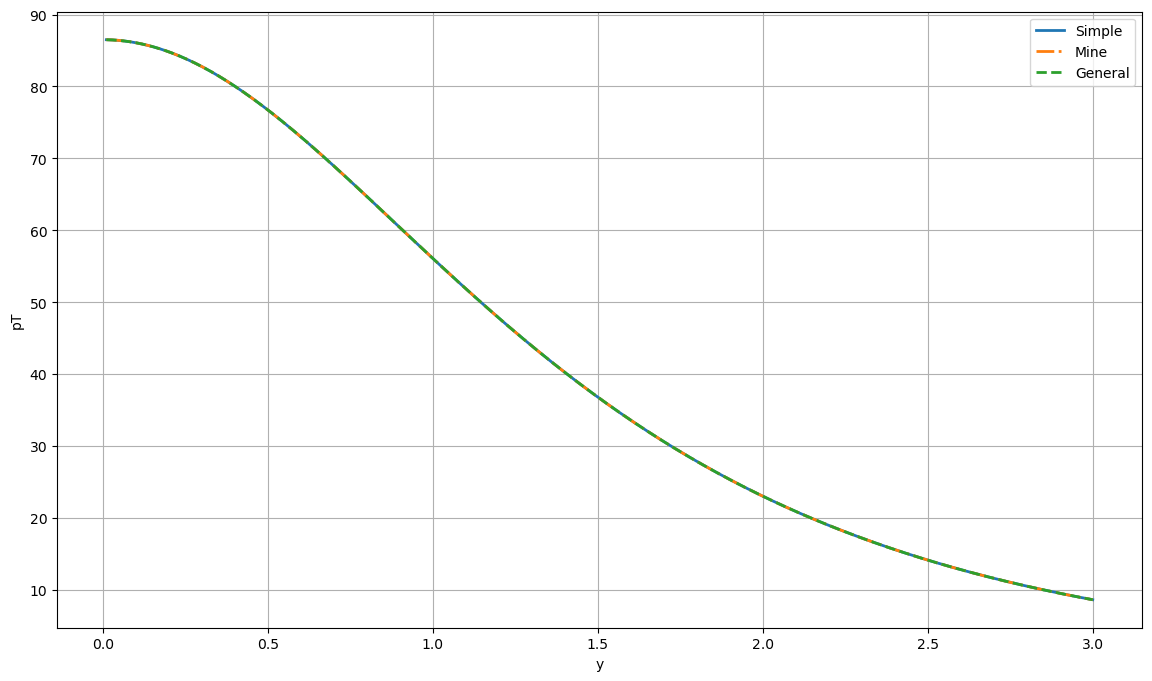

In [2]:
def pT_2massless(M, m3, m4, y):
    pT = M / ( 2 * np.cosh(y) )
    return pT

def pT_2massless_gen(M, m3, m4, y):
    num = M**2 * (-1 + np.cosh(2*y))
    dem = 2 * (np.cosh(2*y)**2 - 1)
    pT = np.sqrt( num / dem )
    return pT 

m3, m4 = 0, 0   # Example light or massless partner

two_massless = np.array([pT_2massless(M, m3, m4, y) for y in y_vals])
two_massless_mine = np.array([pT_2massless_gen(M, m3, m4, y) for y in y_vals])
two_massless_gen = np.array([pT_general(M, m3, m4, y) for y in y_vals])

plt.figure(figsize=(14, 8))

plt.plot(y_vals, two_massless, label ="Simple", lw = 2)
plt.plot(y_vals, two_massless_mine, '-.', label ="Mine", lw = 2)
plt.plot(y_vals, two_massless_gen, '--', label ="General", lw = 2)

plt.xlabel("y")
plt.ylabel("pT")
#plt.ylim(0,90)
#plt.title("")
plt.legend()
plt.grid(True)
plt.show()

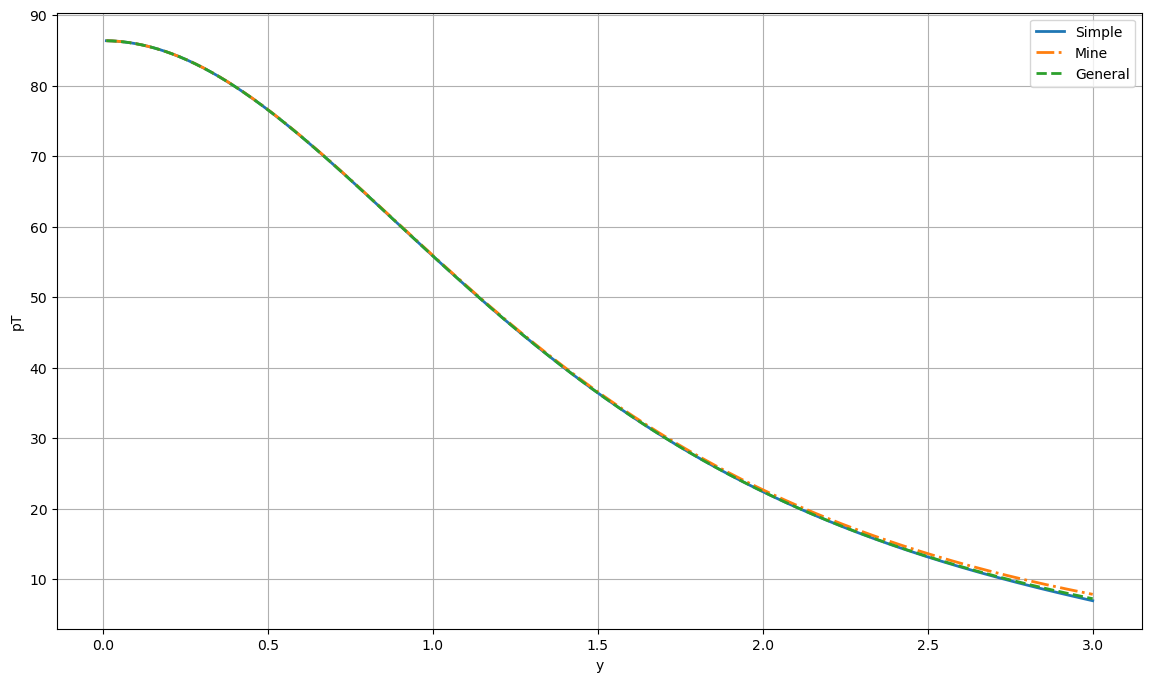

In [6]:
def pT_equal_mass(M, m3, m4, y):
    pT = np.sqrt( M**2 - 4*m3**2*np.cosh(y)**2) / ( 2 * np.cosh(y) )
    return pT

def pT_equal_mass_gen(M, m3, m4, y):
    A = np.cosh(2*y)**2 - 1
    B = M**2 + m3**2 * (np.cosh(2*y)**2 - 1)
    C = (4*m3**2*M**2 - M**4) / 4
    num = - B + np.sqrt( B**2 - 4*A*C )
    dem = 2 * A
    pT = np.sqrt(num / dem)
    return pT 

m3 = 5
m4 = m3

same_mass = np.array([pT_equal_mass(M, m3, m4, y) for y in y_vals])
same_mass_mine = np.array([pT_equal_mass_gen(M, m3, m4, y) for y in y_vals])
same_mass_gen = np.array([pT_general(M, m3, m4, y) for y in y_vals])

plt.figure(figsize=(14, 8))

plt.plot(y_vals, same_mass, label ="Simple", lw = 2)
plt.plot(y_vals, same_mass_mine, '-.', label ="Mine", lw = 2)
plt.plot(y_vals, same_mass_gen, '--', label ="General", lw = 2)

plt.xlabel("y")
plt.ylabel("pT")
#plt.ylim(0,90)
#plt.title("")
plt.legend()
plt.grid(True)
plt.show()

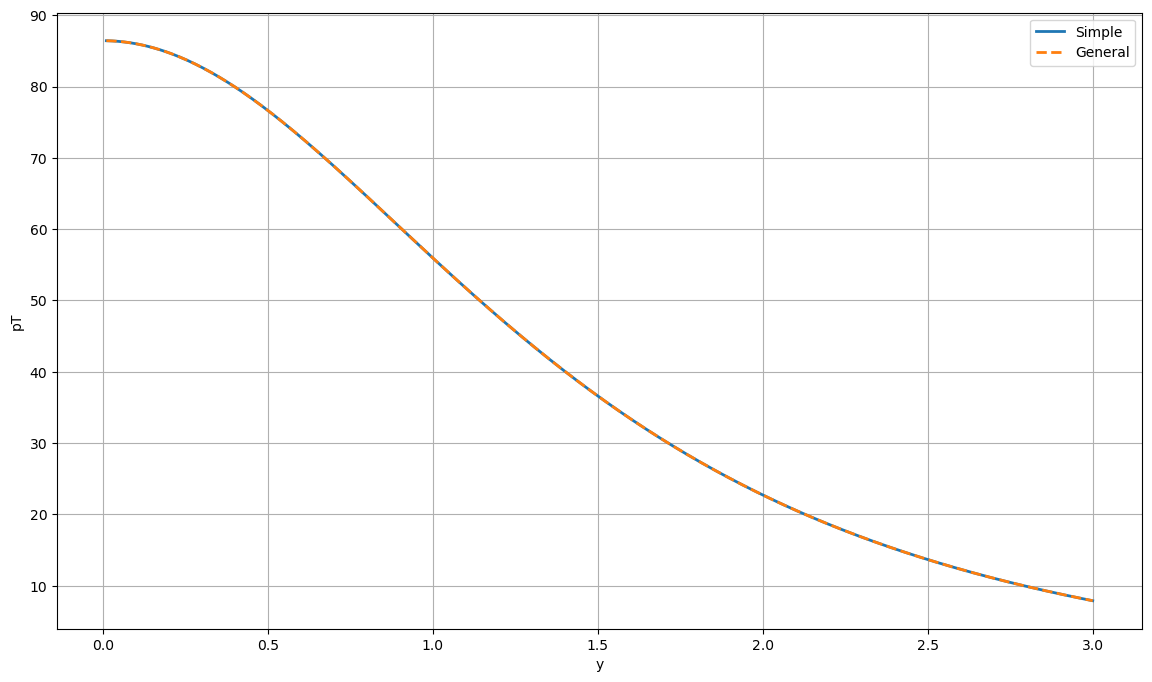

In [5]:
def pT_masslessXmassive_STRINGS(M, m3, m4, y):
    cosh2y = math.cosh(2*y)
    d = (2 * (M**2)) / ((cosh2y**2) - 1)
    c = (2 * (m3**2)) / ((cosh2y**2) - 1)
    b = (2 * (m3**2) * (cosh2y**2)) / ((cosh2y**2) - 1)
    a = (math.sqrt(2) * math.sqrt((cosh2y**2) * ((m3**4) * math.cosh(4*y) - (m3**4) + 2*(M**4)))) / ((cosh2y**2) - 1)
    pt = 0.5 * math.sqrt(a - b + c - d)
    return pt

def pT_masslessXmassive_gen(M, m3, m4, y):
    a = ( M**2 - m3**2 ) / 2
    A = np.cosh(2*y)**2 - 1
    B = 2*a + m3**2*np.cosh(2*y)**2
    C = a**2
    pT = np.sqrt( - (-B + np.sqrt(B**2 - 4*A*C)) / (2*A) )
    return pT
    #return abs(pT)
    
m3 = 5 
m4 = 0 

STRINGS = np.array([pT_masslessXmassive_STRINGS(M, m3, m4, y) for y in y_vals])
#mine = np.array([pT_masslessXmassive_gen(M, m3, m4, y) for y in y_vals])
gen = np.array([pT_general(M, m3, m4, y) for y in y_vals])

plt.figure(figsize=(14, 8))

plt.plot(y_vals, STRINGS, label ="Simple", lw = 2)
#plt.plot(y_vals, mine, '-.', label ="Mine", lw = 2)
plt.plot(y_vals, gen, '--', label ="General", lw = 2)

plt.xlabel("y")
plt.ylabel("pT")
#plt.ylim(0,90)
#plt.title("")
plt.legend()
plt.grid(True)
plt.show()

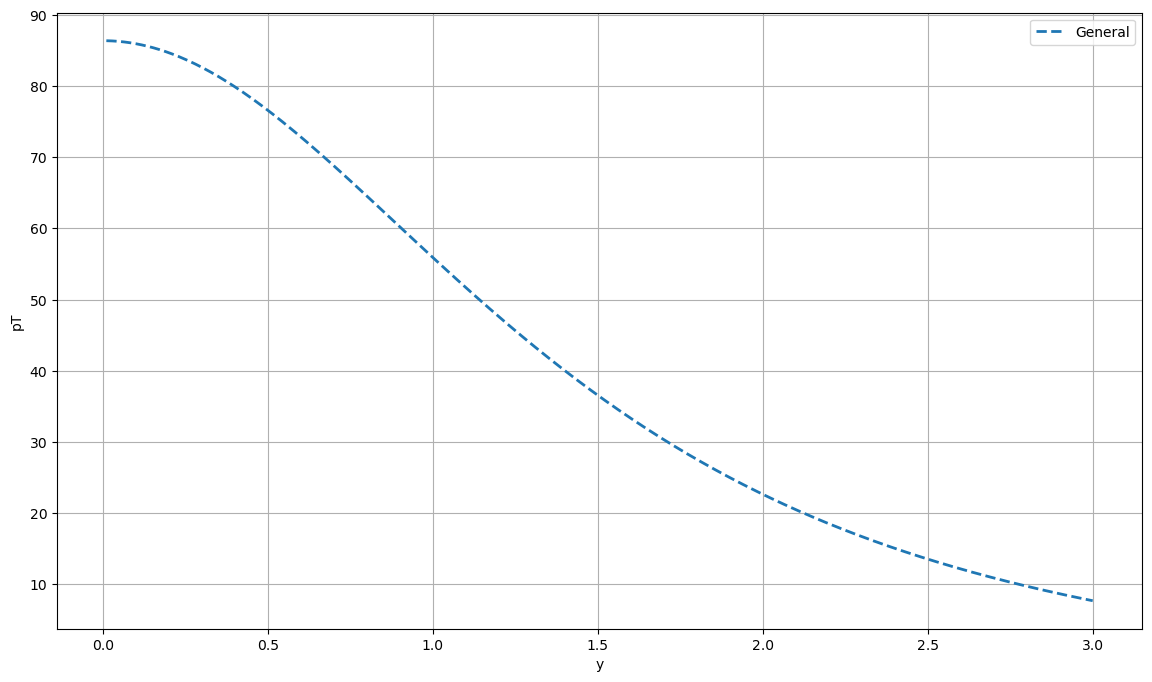

In [7]:
m3 = 5 
m4 = 3

gen = np.array([pT_general(M, m3, m4, y) for y in y_vals])

plt.figure(figsize=(14, 8))

plt.plot(y_vals, gen, '--', label ="General", lw = 2)

plt.xlabel("y")
plt.ylabel("pT")
#plt.ylim(0,90)
#plt.title("")
plt.legend()
plt.grid(True)
plt.show()